In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys
import os
import matsim
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from shapely.geometry import Point, box


# Carrier locations

In [57]:
DepotLocation = {
    "INSIDE": {
        'bottom_left': "3390195_0",
        'bottom_right': "893781380_r_0-48247088_0",
        'upper_right': "10149534_2",
        'upper_left': "150056709_r_10",
    },
    "OUTSIDE": {
        'left': "333784188_r_3",
        'right': "27566523_11",
        'up': "25806807_r_1",
        'down': "131757263_1-131757263_2",
    },
}

# Read Leuven network

<Axes: >

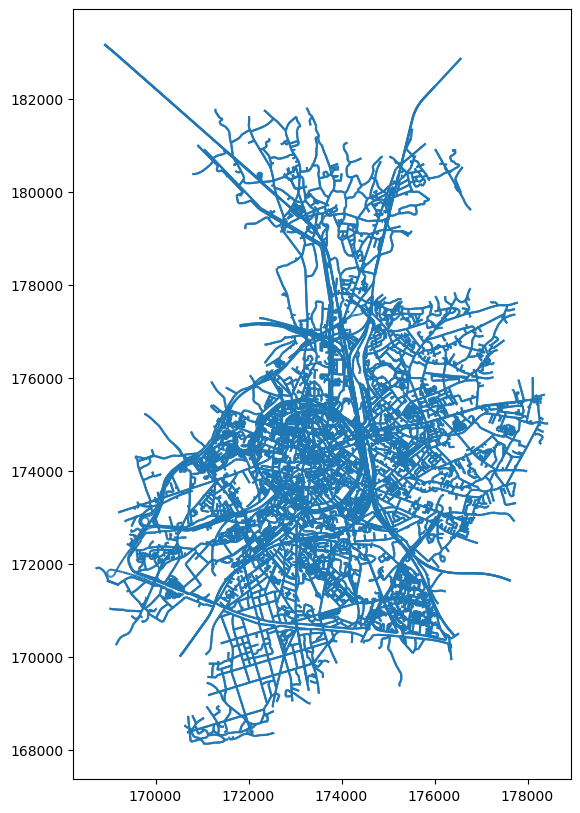

In [3]:
network_path = r'data/GemeenteLeuvenWithHbefaType/GemeenteLeuvenWithHbefaType.xml.gz'
network = matsim.read_network(network_path)
# convert to geopandas GeoDataFrame
network_gdf = network.as_geo()
network_gdf.plot(figsize=(10, 10))

In [63]:
car_network_gdf = network_gdf[network_gdf['modes'].str.contains('car')]
print('car network size:', car_network_gdf.size)
print('original network gdf size:', network_gdf.size)

car network size: 522040
original network gdf size: 1037530


<Axes: >

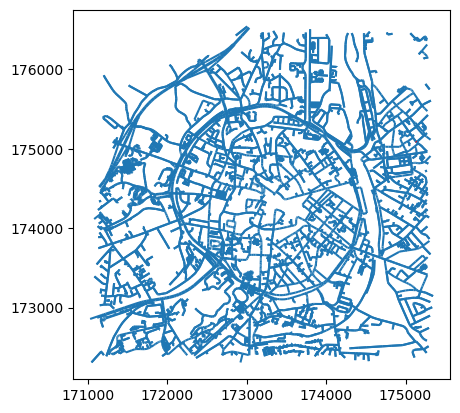

In [75]:
# Crop the network to the area of interest (Xmin:172161.734, Xmax:174265.856, Ymin:173412.828, Ymax:175444.093)
fig, ax = plt.subplots()
bbox = (171161.734, 175265.856, 172412.828, 176444.093)
network_gdf_cropped = car_network_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
network_gdf_cropped.plot(ax=ax)
car_network_gdf.query("link_id == '27566523_11'").plot(color='red', ax=ax)

<Axes: >

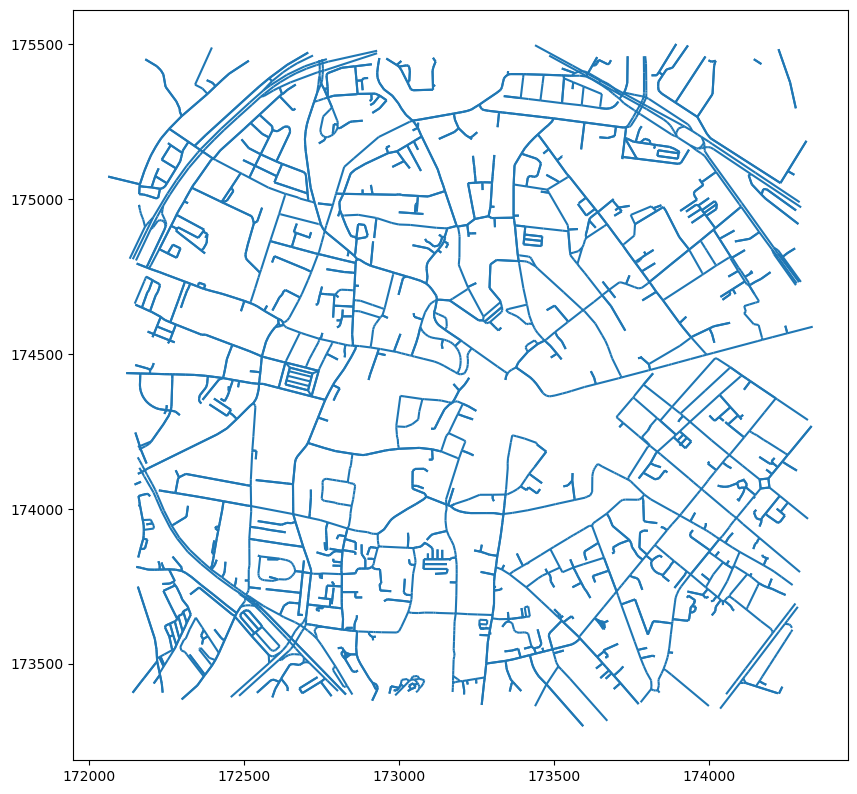

In [ ]:
# # Crop the network to the area of interest (Xmin:172161.734, Xmax:174265.856, Ymin:173412.828, Ymax:175444.093)
# bbox = (172161.734, 174265.856, 173412.828, 175444.093)
# network_gdf_cropped4customer = car_network_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
# network_gdf_cropped4customer.plot(figsize=(10, 10))

# Path

In [6]:
data_dir = r'data/leuven_poi/data/'
os.listdir(data_dir)

['poi-osm-point.gpkg',
 'order_boundary.gpkg',
 'poi-overture-point.gpkg',
 'poi-fsq-point.gpkg',
 'poi-osm-polygon.gpkg']

In [7]:
fsq_poi_data_path = os.path.join(data_dir, 'poi-fsq-point.gpkg')
fsq_poi_gdf = gpd.read_file(fsq_poi_data_path)
fsq_poi_gdf

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
0,54f08a04498e311c6623740f,Het Bos,50.937848,4.733698,None,None,None,None,None,None,...,None,None,None,Landmarks and Outdoors,Tree,None,None,None,None,POINT (4.7337 50.93785)
1,4fd1bd87e4b03e7cedf5302c,Alteco,50.935559,4.726363,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Factory,None,None,None,None,POINT (4.72636 50.93556)
2,1dc816dd49ad4ab93d65637b,Dh Consult,50.935206,4.727068,Jef Scherensstraat 1,Wilsele,Vlaams-Brabant,3012,None,None,...,None,None,None,Business and Professional Services,Repair Service,None,None,None,None,POINT (4.72707 50.93521)
3,52c99d0e11d2356fb2817919,Legends Retro Café,50.936746,4.731189,Aarschotsesteenweg 749,Wilsele,Vlaams brabant,3012,None,None,...,None,None,None,Dining and Drinking,Bar,None,None,None,None,POINT (4.73119 50.93675)
4,57418dbb498e8a0626d2a2fd,Locked Escape Room Leuven,50.936682,4.731218,Aarschotsesteenweg 749,Wilsele,None,None,None,None,...,None,None,None,Arts and Entertainment,Escape Room,None,None,None,None,POINT (4.73122 50.93668)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23576,20fb60f468df44fd37157340,Krima,50.904575,4.721743,Wilselsesteenweg 257,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (4.72174 50.90458)
23577,3d940afa0dda420f017635a0,Bob de veiligheidscoördinator,50.905838,4.745195,Holsbeeksesteenweg 385,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (4.7452 50.90584)
23578,58822c09ca10705c93bb8ede,Rozenpad,50.888630,4.767532,Rozenpad,Leuven,None,3010,None,None,...,None,None,None,Landmarks and Outdoors,Forest,None,None,None,None,POINT (4.76753 50.88863)
23579,4cc44ce282388cfae6ed6d35,Zidazo,50.885448,4.768265,Lange Lostraat 46,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,Business and Professional Services,Office,None,None,None,None,POINT (4.76826 50.88545)


In [8]:
# Conver the crs to Leuven network crs (EPSG:31370)
fsq_poi_gdf = fsq_poi_gdf.to_crs(epsg=31370)
fsq_poi_gdf

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
0,54f08a04498e311c6623740f,Het Bos,50.937848,4.733698,None,None,None,None,None,None,...,None,None,None,Landmarks and Outdoors,Tree,None,None,None,None,POINT (175741.695 180842.237)
1,4fd1bd87e4b03e7cedf5302c,Alteco,50.935559,4.726363,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Factory,None,None,None,None,POINT (175227.31 180585.077)
2,1dc816dd49ad4ab93d65637b,Dh Consult,50.935206,4.727068,Jef Scherensstraat 1,Wilsele,Vlaams-Brabant,3012,None,None,...,None,None,None,Business and Professional Services,Repair Service,None,None,None,None,POINT (175277.058 180546.047)
3,52c99d0e11d2356fb2817919,Legends Retro Café,50.936746,4.731189,Aarschotsesteenweg 749,Wilsele,Vlaams brabant,3012,None,None,...,None,None,None,Dining and Drinking,Bar,None,None,None,None,POINT (175565.885 180718.734)
4,57418dbb498e8a0626d2a2fd,Locked Escape Room Leuven,50.936682,4.731218,Aarschotsesteenweg 749,Wilsele,None,None,None,None,...,None,None,None,Arts and Entertainment,Escape Room,None,None,None,None,POINT (175567.996 180711.705)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23576,20fb60f468df44fd37157340,Krima,50.904575,4.721743,Wilselsesteenweg 257,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174918.993 177136.702)
23577,3d940afa0dda420f017635a0,Bob de veiligheidscoördinator,50.905838,4.745195,Holsbeeksesteenweg 385,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (176567.917 177285.334)
23578,58822c09ca10705c93bb8ede,Rozenpad,50.888630,4.767532,Rozenpad,Leuven,None,3010,None,None,...,None,None,None,Landmarks and Outdoors,Forest,None,None,None,None,POINT (178149.395 175379.278)
23579,4cc44ce282388cfae6ed6d35,Zidazo,50.885448,4.768265,Lange Lostraat 46,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,Business and Professional Services,Office,None,None,None,None,POINT (178202.883 175025.579)


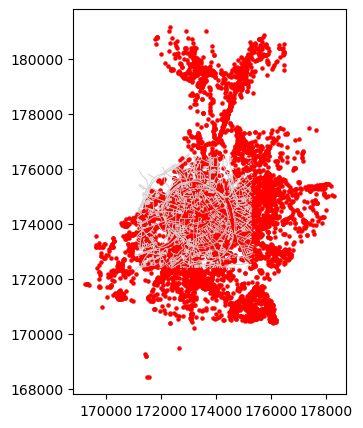

In [74]:
# visualize the cropped network and POIs
fig, ax = plt.subplots(figsize=(5, 5))
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf.plot(ax=ax, color='red', markersize=5)
plt.show()

In [77]:
# Filter out POIs that are within the cropped network area
fsq_poi_gdf_cropped = fsq_poi_gdf.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
fsq_poi_gdf_cropped

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
775,64a13843f7de6365ba8e38b3,aarschotseweg,50.897848,4.691090,None,None,None,None,None,None,...,None,None,None,Travel and Transportation,Road,None,None,None,None,POINT (172766.086 176378.517)
972,53a3ea96498ea256c9261f03,OS Kesseldallaan,50.897939,4.716599,None,None,None,None,None,None,...,None,None,None,Landmarks and Outdoors,Monument,None,None,None,None,POINT (174560.647 176396.79)
976,54c4ddd7498e05bbd67866fb,spaghettiweekend damiaansouts wilsele,50.898157,4.718398,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Restaurant,Burger Joint,None,None,None,POINT (174687.076 176421.618)
977,550deb80498ec85c1160419d,Wilsele On Fire,50.897645,4.718099,None,None,None,None,None,None,...,None,None,None,Event,Other Event,None,None,None,None,POINT (174666.286 176364.581)
978,5b55aad6838e59002cecdb7e,Ponywerking Sporty,50.896983,4.717667,None,Kessel-Lo,Vlaams-Brabant,3010,None,None,...,None,None,None,Landmarks and Outdoors,Stable,None,None,None,None,POINT (174636.266 176290.774)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23552,0e225d5e06fc472556177cea,Loomans D,50.886913,4.721691,Gemeentestraat 66,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174924.708 175171.889)
23553,3b540f9fbea7dad4c9f2cda2,PostNL Pakketpunt,50.887594,4.722489,Gemeentestraat 69,Leuven,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174980.499 175247.915)
23554,3376ec70f50b481e9d7d34bd,Stabel Geert Bvba,50.886574,4.719212,"Eenmeilaan, 20",Louvain,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174750.446 175133.348)
23555,d6880b83a2fe43bd5d534604,Tweestroom architecten B.V. Bvba,50.887126,4.718816,Eenmeilaan 29,Kessel-Lo,Vlaams-Brabant,3010,None,None,...,None,None,None,None,None,None,None,None,None,POINT (174722.289 175194.623)


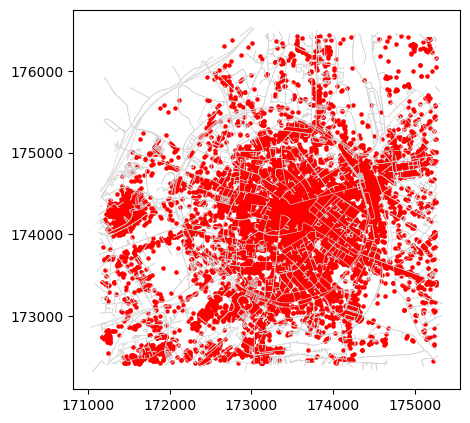

In [78]:
# visualize the cropped network and POIs
fig, ax = plt.subplots(figsize=(5, 5))
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped.plot(ax=ax, color='red', markersize=5)
plt.show()

## filter out the irrelevant POIs
- Since we aim to generate customers/receivers in the context of Urban freight system, we need to filter out those irrelevant POIs (e.g., tree, park, etc)

### Get the categories of the POIs

In [79]:
category_level_one = fsq_poi_gdf_cropped['cat1_name'].unique()
print(len(category_level_one))
category_level_one

11


array(['Travel and Transportation', 'Landmarks and Outdoors',
       'Dining and Drinking', 'Event',
       'Business and Professional Services', 'Sports and Recreation',
       'Retail', 'Arts and Entertainment', 'Health and Medicine',
       'Community and Government', None], dtype=object)

In [80]:
''' 
Basically, we can identify only "'Business and Professional Services'(optional), 'Dining and Drinking',
       'Retail'" - 3 main categories in level one categories could be related to freight delivery.
'''
useful_cat_level_one = [
                        'Business and Professional Services',
                        'Dining and Drinking',
                        'Retail']
fsq_poi_gdf_cropped_filtered_level_one = fsq_poi_gdf_cropped[fsq_poi_gdf_cropped['cat1_name'].isin(useful_cat_level_one)]
fsq_poi_gdf_cropped_filtered_level_one

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat4_id,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry
976,54c4ddd7498e05bbd67866fb,spaghettiweekend damiaansouts wilsele,50.898157,4.718398,None,None,None,None,None,None,...,None,None,None,Dining and Drinking,Restaurant,Burger Joint,None,None,None,POINT (174687.076 176421.618)
979,5704de73498eecd5fe12c036,CityDepot Leuven,50.897485,4.709923,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Distribution Center,None,None,None,None,POINT (174091.198 176344.078)
988,5b1bc112835c9a002c154d77,Eetcafé De Stordeur,50.898279,4.706337,Aarschotsesteenweg 112,Wilsele,Vlaams-Brabant,3012,None,None,...,57558b36e4b065ecebd306b0,None,None,Dining and Drinking,Restaurant,French Restaurant,Brasserie,None,None,POINT (173838.514 176431.249)
996,50584c85e4b079bf3ac40a18,Metaleuven IJzermagazijn,50.898356,4.708001,None,None,None,None,None,None,...,None,None,None,Retail,Hardware Store,None,None,None,None,POINT (173955.513 176440.351)
998,54496376498e175d6fef1c89,Warehouse O'cool,50.897022,4.707874,Aarschotsesteenweg,Wilsele,Vlaams-Brabant,3012,None,None,...,None,None,None,Business and Professional Services,Warehouse,None,None,None,None,POINT (173947.263 176291.919)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22675,ba760b86990b41e9f698961b,Helleboogh,50.895802,4.726543,Bruineveld 132/A,Kessel-Lo,Vlaams-Brabant,3010,None,None,...,None,None,None,Business and Professional Services,Repair Service,None,None,None,None,POINT (175261.35 176162.377)
22678,56d978f4498e3f094b909bfa,High School Musical,50.893784,4.725048,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Health and Beauty Service,Bath House,None,None,None,POINT (175157.251 175937.379)
22681,4fa132afe4b0b6a5a226bc72,Notaris Vandeweghe,50.891609,4.725080,None,None,None,None,None,None,...,None,None,None,Business and Professional Services,Legal Service,Notary,None,None,None,POINT (175160.681 175695.418)
22682,5357d57e498e672d3d6aea88,Notarissen Boes & Leroy,50.891694,4.725119,Leopold Ruelensstraat 54,Kessel-Lo,None,3010,None,None,...,None,None,None,Business and Professional Services,Legal Service,Notary,None,None,None,POINT (175163.38 175704.891)


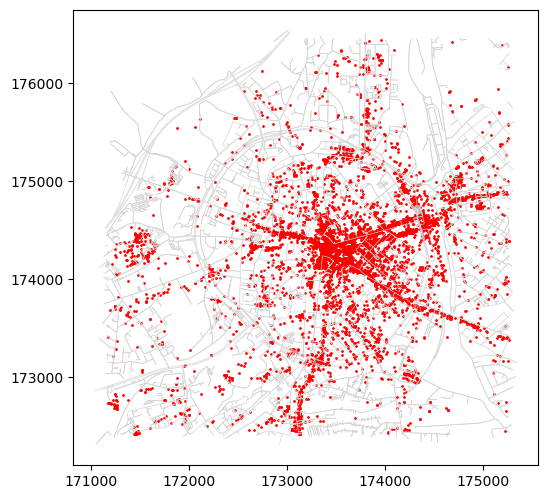

In [81]:
# visualize the cropped network and POIs
fig, ax = plt.subplots(figsize=(6, 6))
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped_filtered_level_one.plot(ax=ax, color='red', markersize=1)
plt.show()

In [68]:
category_level_two = fsq_poi_gdf_cropped_filtered_level_one['cat2_name'].unique()
print(len(category_level_two))
category_level_two

130


array(['Health and Beauty Service', 'Restaurant', 'Drugstore', 'Bar',
       'Office', 'Business Service', 'Automotive Service', None,
       'Dessert Shop', 'Convenience Store', 'Night Market',
       'Food and Beverage Service', 'Convention Center',
       'Food and Beverage Retail', 'Advertising Agency', 'Event Space',
       'Food Truck', 'Cafe, Coffee, and Tea House',
       'Furniture and Home Store', 'Arts and Crafts Store',
       'Business Center', 'Technology Business',
       'Computers and Electronics Retail', 'Discount Store',
       'Cosmetics Store', 'Baby Store', 'Fashion Retail',
       'Sporting Goods Retail', 'Boutique', 'Design Studio',
       'Financial Service', 'Legal Service', 'TV Station',
       'Employment Agency', 'Miscellaneous Store', 'Distillery',
       'Factory', 'Brewery', 'Automotive Retail', 'Warehouse',
       'Print Store', 'Toy Store', 'Repair Service', 'Architecture Firm',
       'Human Resources Agency', 'Pharmacy', 'Cafeteria',
       'Child Ca

# Customer Generation Scenarios (Depot-Based)

We implement 4 scenarios based on depot location and customer distribution:

| Scenario | Depot Location | Customer Distribution |
|----------|---------------|----------------------|
| 1 | Inside (4 depots) | Clustered around depots |
| 2 | Inside (4 depots) | Uniformly dispersed |
| 3 | Outside (4 depots) | Clustered (reuse from Scenario 1, reassign to nearest outside depot) |
| 4 | Outside (4 depots) | Dispersed (reuse from Scenario 2, reassign to nearest outside depot) |

In [82]:
def get_depot_coordinates(
    depot_dict: dict,
    network_gdf: gpd.GeoDataFrame,
    depot_type: str = "INSIDE"
) -> dict:
    """
    Get the coordinates of depots from link IDs.
    
    Parameters
    ----------
    depot_dict : dict
        DepotLocation dictionary with 'INSIDE' and 'OUTSIDE' keys.
    network_gdf : GeoDataFrame
        Network with link geometries.
    depot_type : str
        'INSIDE' or 'OUTSIDE'.
    
    Returns
    -------
    dict
        {depot_name: (x, y)} coordinates (centroid of link geometry).
    """
    depot_coords = {}
    for name, link_id in depot_dict[depot_type].items():
        link = network_gdf[network_gdf['link_id'] == link_id]
        if len(link) > 0:
            geom = link.geometry.iloc[0]
            centroid = geom.centroid
            depot_coords[name] = (centroid.x, centroid.y)
        else:
            print(f"Warning: Link {link_id} not found in network")
    return depot_coords


def generate_customers_clustered_by_depot(
    poi_gdf: gpd.GeoDataFrame,
    depot_coords: dict,
    n_customers: int = 100,
    sigma: float = 300.0,
    d_min: float = 50.0,
    random_state: int = 42,
) -> gpd.GeoDataFrame:
    """
    Generate clustered customers around specified depot locations.
    Each depot receives n_customers / n_depots customers.
    
    Parameters
    ----------
    poi_gdf : GeoDataFrame
        Source POI points (already filtered).
    depot_coords : dict
        {depot_name: (x, y)} coordinates of depots.
    n_customers : int
        Total number of customers to generate.
    sigma : float
        Cluster spread (meters). Smaller = tighter clusters around depots.
    d_min : float
        Minimum distance (meters) between any two customers.
    random_state : int
        Random seed.
    
    Returns
    -------
    GeoDataFrame
        Customers with 'depot_name' column indicating assigned depot.
    """
    rng = np.random.default_rng(random_state)
    coords = np.array([(p.x, p.y) for p in poi_gdf.geometry])
    
    depot_names = list(depot_coords.keys())
    n_depots = len(depot_names)
    centers = np.array([depot_coords[name] for name in depot_names])
    
    # Allocate customers evenly per depot
    base_count = n_customers // n_depots
    remainder = n_customers % n_depots
    depot_sizes = [base_count + (1 if i < remainder else 0) for i in range(n_depots)]
    
    selected_indices = []
    assigned_depots = []
    
    for k, depot_name in enumerate(depot_names):
        n_k = depot_sizes[k]
        if n_k == 0:
            continue
        
        center = centers[k]
        # Compute Gaussian weights centered at depot
        dists = np.linalg.norm(coords - center, axis=1)
        weights = np.exp(-dists**2 / (2 * sigma**2))
        weights /= weights.sum()
        
        sampled = []
        attempts = 0
        max_attempts = n_k * 100
        
        while len(sampled) < n_k and attempts < max_attempts:
            attempts += 1
            # Pool of available POIs (not yet selected)
            mask = np.isin(np.arange(len(coords)), selected_indices + sampled, invert=True)
            pool = np.where(mask)[0]
            if len(pool) == 0:
                break
            
            w = weights[pool]
            w /= w.sum()
            choice = rng.choice(pool, p=w)
            
            # Check d_min constraint
            if len(sampled) > 0:
                sampled_coords = coords[sampled]
                if np.min(np.linalg.norm(sampled_coords - coords[choice], axis=1)) < d_min:
                    continue
            if len(selected_indices) > 0:
                sel_coords = coords[selected_indices]
                if np.min(np.linalg.norm(sel_coords - coords[choice], axis=1)) < d_min:
                    continue
            
            sampled.append(choice)
        
        selected_indices.extend(sampled)
        assigned_depots.extend([depot_name] * len(sampled))
    
    result = poi_gdf.iloc[selected_indices].copy()
    result['depot_name'] = assigned_depots
    result = result.reset_index(drop=True)
    return result


def generate_customers_dispersed_by_depot(
    poi_gdf: gpd.GeoDataFrame,
    depot_coords: dict,
    n_customers: int = 100,
    grid_size: float = 200.0,
    d_min: float = 50.0,
    random_state: int = 42,
) -> gpd.GeoDataFrame:
    """
    Generate uniformly dispersed customers, evenly distributed among depots.
    Each depot's customers are spatially spread across the study area.
    
    Parameters
    ----------
    poi_gdf : GeoDataFrame
        Source POI points.
    depot_coords : dict
        {depot_name: (x, y)} coordinates of depots.
    n_customers : int
        Total number of customers.
    grid_size : float
        Grid cell size for stratified sampling.
    d_min : float
        Minimum distance between customers.
    random_state : int
        Random seed.
    
    Returns
    -------
    GeoDataFrame
        Customers with 'depot_name' column.
    """
    rng = np.random.default_rng(random_state)
    poi_gdf = poi_gdf.copy().reset_index(drop=True)
    coords = np.array([(p.x, p.y) for p in poi_gdf.geometry])
    
    depot_names = list(depot_coords.keys())
    n_depots = len(depot_names)
    
    # Build grid
    xmin, ymin, xmax, ymax = poi_gdf.total_bounds
    x_edges = np.arange(xmin, xmax + grid_size, grid_size)
    y_edges = np.arange(ymin, ymax + grid_size, grid_size)
    
    poi_gdf['_grid_x'] = np.digitize(coords[:, 0], x_edges) - 1
    poi_gdf['_grid_y'] = np.digitize(coords[:, 1], y_edges) - 1
    poi_gdf['_grid_id'] = poi_gdf['_grid_x'].astype(str) + '_' + poi_gdf['_grid_y'].astype(str)
    
    cell_groups = {gid: grp.index.tolist() for gid, grp in poi_gdf.groupby('_grid_id')}
    
    # Customers per depot
    base_count = n_customers // n_depots
    remainder = n_customers % n_depots
    customers_per_depot = [base_count + (1 if i < remainder else 0) for i in range(n_depots)]
    
    all_selected = []
    all_depot_names = []
    global_selected = set()
    
    for depot_idx, depot_name in enumerate(depot_names):
        n_for_depot = customers_per_depot[depot_idx]
        depot_selected = []
        attempts = 0
        max_attempts = n_for_depot * 100
        
        local_cells = {c: [i for i in idx if i not in global_selected] for c, idx in cell_groups.items()}
        local_cells = {c: idx for c, idx in local_cells.items() if len(idx) > 0}
        cell_list = list(local_cells.keys())
        
        while len(depot_selected) < n_for_depot and attempts < max_attempts:
            attempts += 1
            if not cell_list:
                break
            
            cell = rng.choice(cell_list)
            candidates = [c for c in local_cells[cell] if c not in global_selected and c not in depot_selected]
            if not candidates:
                cell_list = [c for c in cell_list if c != cell]
                continue
            
            choice = rng.choice(candidates)
            
            # d_min check
            if len(depot_selected) > 0:
                sel_coords = coords[depot_selected]
                if np.min(np.linalg.norm(sel_coords - coords[choice], axis=1)) < d_min:
                    continue
            
            depot_selected.append(choice)
            local_cells[cell] = [c for c in local_cells[cell] if c != choice]
            if len(local_cells[cell]) == 0:
                cell_list = [c for c in cell_list if c != cell]
        
        global_selected.update(depot_selected)
        all_selected.extend(depot_selected)
        all_depot_names.extend([depot_name] * len(depot_selected))
    
    result = poi_gdf.loc[all_selected].copy()
    result['depot_name'] = all_depot_names
    result = result.drop(columns=['_grid_x', '_grid_y', '_grid_id'], errors='ignore')
    result = result.reset_index(drop=True)
    return result


def reassign_customers_to_outside_depots(
    customers_gdf: gpd.GeoDataFrame,
    inside_depot_coords: dict,
    outside_depot_coords: dict,
) -> gpd.GeoDataFrame:
    """
    Reassign customers from inside depots to nearest outside depots.
    
    Mapping logic:
    - bottom_left -> down
    - bottom_right -> right  
    - upper_left -> left
    - upper_right -> up
    
    Parameters
    ----------
    customers_gdf : GeoDataFrame
        Customers with 'depot_name' column (inside depot names).
    inside_depot_coords : dict
        Inside depot coordinates.
    outside_depot_coords : dict
        Outside depot coordinates.
    
    Returns
    -------
    GeoDataFrame
        Customers with updated 'depot_name' pointing to outside depots.
    """
    # Define mapping from inside to outside depots
    depot_mapping = {
        'bottom_left': 'down',
        'bottom_right': 'right',
        'upper_left': 'left',
        'upper_right': 'up',
    }
    
    result = customers_gdf.copy()
    result['depot_name'] = result['depot_name'].map(depot_mapping)
    return result

## Get Depot Coordinates from Network

In [83]:
# Get depot coordinates from network
inside_depot_coords = get_depot_coordinates(DepotLocation, car_network_gdf, "INSIDE")
outside_depot_coords = get_depot_coordinates(DepotLocation, car_network_gdf, "OUTSIDE")

print("Inside Depots:")
for name, coord in inside_depot_coords.items():
    print(f"  {name}: ({coord[0]:.2f}, {coord[1]:.2f})")

print("\nOutside Depots:")
for name, coord in outside_depot_coords.items():
    print(f"  {name}: ({coord[0]:.2f}, {coord[1]:.2f})")

Inside Depots:
  bottom_left: (172619.82, 173735.72)
  bottom_right: (173782.04, 173651.17)
  upper_right: (173795.96, 174939.83)
  upper_left: (172624.94, 175165.86)

Outside Depots:
  left: (171313.17, 174678.37)
  right: (175134.38, 175088.91)
  up: (173417.57, 175842.79)
  down: (172976.72, 173030.26)


## Scenario 1 & 2: Inside Depots - Clustered & Dispersed Customers

In [101]:
# Configuration
N_CUSTOMERS = 60  # Total customers (10 per depot for 4 depots)
SIGMA = 250.0     # Cluster spread in meters (smaller = more clustered)
D_MIN = 50.0      # Minimum distance between customers
RANDOM_STATE = 40

# Scenario 1: Inside Depots + Clustered Customers
customers_inside_clustered = generate_customers_clustered_by_depot(
    fsq_poi_gdf_cropped_filtered_level_one,
    inside_depot_coords,
    n_customers=N_CUSTOMERS,
    sigma=SIGMA,
    d_min=D_MIN,
    random_state=RANDOM_STATE,
)
print(f"Scenario 1 (Inside-Clustered): {len(customers_inside_clustered)} customers")
print(customers_inside_clustered['depot_name'].value_counts())

Scenario 1 (Inside-Clustered): 60 customers
depot_name
bottom_left     15
bottom_right    15
upper_right     15
upper_left      15
Name: count, dtype: int64


In [105]:
# Scenario 2: Inside Depots + Dispersed Customers
customers_inside_dispersed = generate_customers_dispersed_by_depot(
    fsq_poi_gdf_cropped_filtered_level_one,
    inside_depot_coords,
    n_customers=N_CUSTOMERS,
    grid_size=800.0,
    d_min=D_MIN,
    random_state=RANDOM_STATE,
)
print(f"Scenario 2 (Inside-Dispersed): {len(customers_inside_dispersed)} customers")
print(customers_inside_dispersed['depot_name'].value_counts())

Scenario 2 (Inside-Dispersed): 60 customers
depot_name
bottom_left     15
bottom_right    15
upper_right     15
upper_left      15
Name: count, dtype: int64


## Scenario 3 & 4: Outside Depots - Reassign Customers

In [106]:
# Scenario 3: Outside Depots + Clustered Customers (same locations as Scenario 1, reassigned)
customers_outside_clustered = reassign_customers_to_outside_depots(
    customers_inside_clustered,
    inside_depot_coords,
    outside_depot_coords,
)
print(f"Scenario 3 (Outside-Clustered): {len(customers_outside_clustered)} customers")
print(customers_outside_clustered['depot_name'].value_counts())

# Scenario 4: Outside Depots + Dispersed Customers (same locations as Scenario 2, reassigned)
customers_outside_dispersed = reassign_customers_to_outside_depots(
    customers_inside_dispersed,
    inside_depot_coords,
    outside_depot_coords,
)
print(f"\nScenario 4 (Outside-Dispersed): {len(customers_outside_dispersed)} customers")
print(customers_outside_dispersed['depot_name'].value_counts())

Scenario 3 (Outside-Clustered): 60 customers
depot_name
down     15
right    15
up       15
left     15
Name: count, dtype: int64

Scenario 4 (Outside-Dispersed): 60 customers
depot_name
down     15
right    15
up       15
left     15
Name: count, dtype: int64


## Visualize All 4 Scenarios

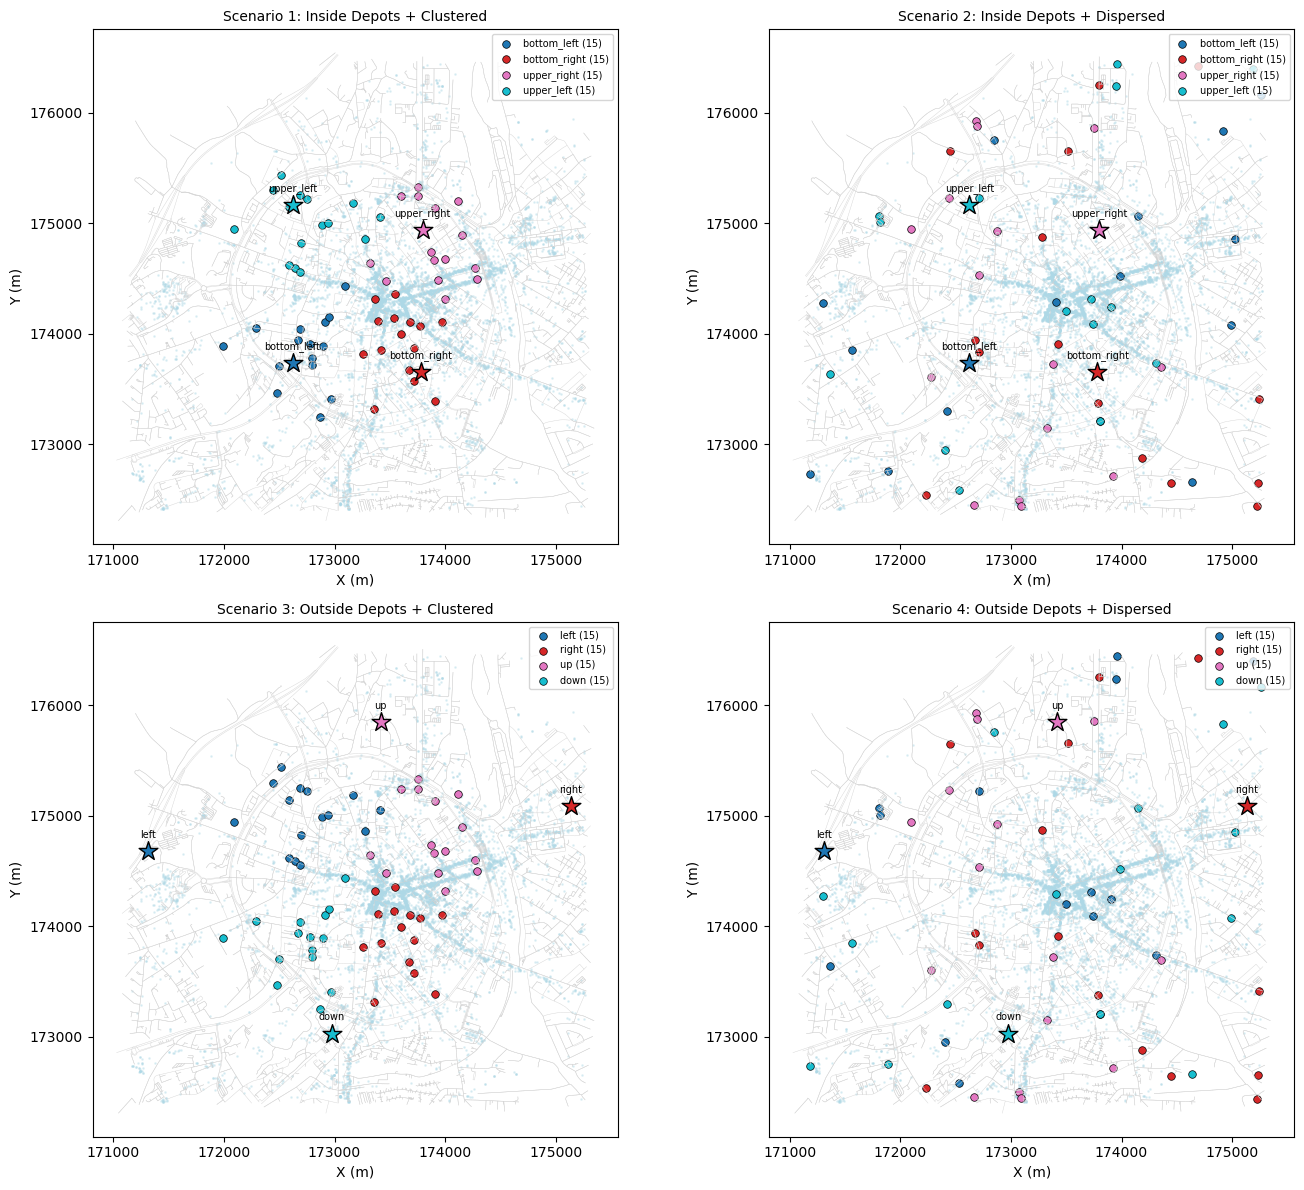

In [107]:
def plot_scenario(ax, customers_gdf, depot_coords, network_gdf, poi_gdf, title):
    """Plot a single scenario with customers, depots, and network."""
    # Plot network
    network_gdf.plot(ax=ax, color='lightgrey', linewidth=0.3)
    
    # Plot all POIs faintly
    poi_gdf.plot(ax=ax, color='lightblue', markersize=1, alpha=0.3)
    
    # Color map for depots
    depot_names = list(depot_coords.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(depot_names)))
    color_map = {name: colors[i] for i, name in enumerate(depot_names)}
    
    # Plot customers colored by depot
    for depot_name in depot_names:
        depot_customers = customers_gdf[customers_gdf['depot_name'] == depot_name]
        if len(depot_customers) > 0:
            depot_customers.plot(ax=ax, color=color_map[depot_name], 
                                markersize=30, edgecolor='k', linewidth=0.5,
                                label=f'{depot_name} ({len(depot_customers)})')
    
    # Plot depot locations as stars
    for depot_name, (x, y) in depot_coords.items():
        ax.scatter(x, y, marker='*', s=200, c=[color_map[depot_name]], 
                  edgecolor='black', linewidth=1, zorder=10)
        ax.annotate(depot_name, (x, y), fontsize=7, ha='center', va='bottom',
                   xytext=(0, 8), textcoords='offset points')
    
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.legend(loc='upper right', fontsize=7)


# Create 2x2 subplot for all scenarios
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Scenario 1: Inside + Clustered
plot_scenario(axes[0, 0], customers_inside_clustered, inside_depot_coords,
              network_gdf_cropped, fsq_poi_gdf_cropped_filtered_level_one,
              "Scenario 1: Inside Depots + Clustered")

# Scenario 2: Inside + Dispersed
plot_scenario(axes[0, 1], customers_inside_dispersed, inside_depot_coords,
              network_gdf_cropped, fsq_poi_gdf_cropped_filtered_level_one,
              "Scenario 2: Inside Depots + Dispersed")

# Scenario 3: Outside + Clustered
plot_scenario(axes[1, 0], customers_outside_clustered, outside_depot_coords,
              network_gdf_cropped, fsq_poi_gdf_cropped_filtered_level_one,
              "Scenario 3: Outside Depots + Clustered")

# Scenario 4: Outside + Dispersed
plot_scenario(axes[1, 1], customers_outside_dispersed, outside_depot_coords,
              network_gdf_cropped, fsq_poi_gdf_cropped_filtered_level_one,
              "Scenario 4: Outside Depots + Dispersed")

plt.tight_layout()
plt.show()

In [108]:
# Match the customer points with the network

# Deprecated

In [34]:
def generate_customers_clustered(
    poi_gdf: gpd.GeoDataFrame,
    n_customers: int = 100,
    n_clusters: int = 5,
    sigma: float = 300.0,
    d_min: float = 50.0,
    random_state: int = 42,
) -> gpd.GeoDataFrame:
    """
    Scenario A: Generate clustered customers (hotspot distribution) using KMeans.
    Each cluster receives an equal number of customers (n_customers / n_clusters).

    Parameters
    ----------
    poi_gdf : GeoDataFrame
        Source POI points (already filtered).
    n_customers : int
        Total number of customers to generate.
    n_clusters : int
        Number of cluster centers.
    sigma : float
        Cluster spread (meters). Smaller = tighter clusters.
    d_min : float
        Minimum distance (meters) between any two customers.
    random_state : int
        Random seed.

    Returns
    -------
    GeoDataFrame
        Selected customer locations with cluster labels (0 to n_clusters-1, evenly distributed).
    """
    rng = np.random.default_rng(random_state)
    coords = np.array([(p.x, p.y) for p in poi_gdf.geometry])

    # A1. Determine cluster centers (KMeans)
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    model.fit(coords)
    centers = model.cluster_centers_

    # A2. Allocate customers evenly per cluster: n_customers / n_clusters
    base_count = n_customers // n_clusters
    remainder = n_customers % n_clusters
    # Each cluster gets base_count, first 'remainder' clusters get 1 extra
    cluster_sizes = np.array([base_count + (1 if i < remainder else 0) for i in range(n_clusters)])

    # A3. Sample customers from each cluster
    selected_indices = []
    assigned_clusters = []  # Track which cluster each customer is assigned to
    
    for k in range(n_clusters):
        n_k = cluster_sizes[k]
        if n_k == 0:
            continue
        # Compute Gaussian weights centered at cluster k
        dists = np.linalg.norm(coords - centers[k], axis=1)
        weights = np.exp(-dists**2 / (2 * sigma**2))
        weights /= weights.sum()

        # Sample without replacement
        available = np.arange(len(coords))
        sampled = []
        attempts = 0
        max_attempts = n_k * 50
        while len(sampled) < n_k and attempts < max_attempts:
            attempts += 1
            # Resample weights for remaining
            mask = np.isin(available, selected_indices + sampled, invert=True)
            pool = available[mask]
            if len(pool) == 0:
                break
            w = weights[pool]
            w /= w.sum()
            choice = rng.choice(pool, p=w)
            # Check d_min constraint
            if len(sampled) > 0:
                sampled_coords = coords[sampled]
                if np.min(np.linalg.norm(sampled_coords - coords[choice], axis=1)) < d_min:
                    continue
            if len(selected_indices) > 0:
                sel_coords = coords[selected_indices]
                if np.min(np.linalg.norm(sel_coords - coords[choice], axis=1)) < d_min:
                    continue
            sampled.append(choice)
        
        selected_indices.extend(sampled)
        assigned_clusters.extend([k] * len(sampled))  # Assign cluster k to all sampled points

    result = poi_gdf.iloc[selected_indices].copy()
    result['cluster'] = assigned_clusters  # Use our assigned cluster, not KMeans labels
    result = result.reset_index(drop=True)
    return result


In [17]:
def generate_customers_dispersed(
    poi_gdf: gpd.GeoDataFrame,
    n_customers: int = 100,
    n_carriers: int = 1,
    grid_size: float = 400.0,
    d_min: float = 50.0,
    random_state: int = 42,
) -> gpd.GeoDataFrame:
    """
    Scenario B: Generate spatially balanced / dispersed customers via stratified grid sampling.
    
    When n_carriers > 1, customers are evenly distributed among carriers, and each carrier's
    customers are spatially dispersed across the study area.

    Parameters
    ----------
    poi_gdf : GeoDataFrame
        Source POI points (already filtered).
    n_customers : int
        Total number of customers to generate.
    n_carriers : int
        Number of carriers to distribute customers among. Each carrier will receive
        approximately n_customers / n_carriers customers with dispersed spatial distribution.
    grid_size : float
        Grid cell edge length (meters).
    d_min : float
        Minimum distance (meters) between any two customers.
    random_state : int
        Random seed.

    Returns
    -------
    GeoDataFrame
        Selected customer locations with grid cell ids and carrier assignments.
    """
    rng = np.random.default_rng(random_state)
    poi_gdf = poi_gdf.copy().reset_index(drop=True)
    coords = np.array([(p.x, p.y) for p in poi_gdf.geometry])

    # Build grid over POI extent
    xmin, ymin, xmax, ymax = poi_gdf.total_bounds
    x_edges = np.arange(xmin, xmax + grid_size, grid_size)
    y_edges = np.arange(ymin, ymax + grid_size, grid_size)

    # Assign each POI to a grid cell
    poi_gdf['_grid_x'] = np.digitize(coords[:, 0], x_edges) - 1
    poi_gdf['_grid_y'] = np.digitize(coords[:, 1], y_edges) - 1
    poi_gdf['_grid_id'] = poi_gdf['_grid_x'].astype(str) + '_' + poi_gdf['_grid_y'].astype(str)

    # Group POIs by grid cell (non-empty cells only)
    cell_groups = {}
    for grid_id, group in poi_gdf.groupby('_grid_id'):
        cell_groups[grid_id] = group.index.tolist()
    non_empty_cells = list(cell_groups.keys())

    # Calculate customers per carrier
    base_count = n_customers // n_carriers
    remainder = n_customers % n_carriers
    customers_per_carrier = [base_count + (1 if i < remainder else 0) for i in range(n_carriers)]

    all_selected_indices = []
    all_carrier_ids = []
    global_selected = set()  # Track all selected indices to avoid duplicates

    for carrier_id in range(n_carriers):
        n_for_carrier = customers_per_carrier[carrier_id]
        carrier_selected = []
        attempts = 0
        max_attempts = n_for_carrier * 100

        # Create a local copy of cell_groups excluding already selected
        local_cell_groups = {
            cell: [idx for idx in indices if idx not in global_selected]
            for cell, indices in cell_groups.items()
        }
        local_non_empty_cells = [cell for cell, indices in local_cell_groups.items() if len(indices) > 0]

        while len(carrier_selected) < n_for_carrier and attempts < max_attempts:
            attempts += 1
            if not local_non_empty_cells:
                break
            # Uniformly sample a non-empty cell
            cell = rng.choice(local_non_empty_cells)
            candidates = local_cell_groups[cell]
            # Remove already selected (both global and local)
            candidates = [c for c in candidates if c not in global_selected and c not in carrier_selected]
            if not candidates:
                # Remove this cell from local non-empty cells
                local_non_empty_cells = [c for c in local_non_empty_cells if c != cell]
                continue
            # Pick one POI from the cell
            choice = rng.choice(candidates)
            # Check d_min constraint against this carrier's selected customers
            if len(carrier_selected) > 0:
                sel_coords = coords[carrier_selected]
                if np.min(np.linalg.norm(sel_coords - coords[choice], axis=1)) < d_min:
                    continue
            carrier_selected.append(choice)
            # Update local cell groups
            local_cell_groups[cell] = [c for c in local_cell_groups[cell] if c != choice]
            if len(local_cell_groups[cell]) == 0:
                local_non_empty_cells = [c for c in local_non_empty_cells if c != cell]

        # Add to global tracking
        global_selected.update(carrier_selected)
        all_selected_indices.extend(carrier_selected)
        all_carrier_ids.extend([carrier_id] * len(carrier_selected))

    result = poi_gdf.loc[all_selected_indices].copy()
    result['grid_id'] = result['_grid_id']
    result['carrier_id'] = all_carrier_ids
    result = result.drop(columns=['_grid_x', '_grid_y', '_grid_id'])
    result = result.reset_index(drop=True)
    return result

## Test: Generate 100 Customers for Each Scenario

In [69]:
# Generate customers for Scenario A (Clustered)
customers_clustered = generate_customers_clustered(
    fsq_poi_gdf_cropped_filtered_level_one,
    n_customers=60,
    n_clusters=4,
    sigma=300,
    # alpha=1.0,
    d_min=50,
    random_state=42,
)
print(f"Scenario A (Clustered): {len(customers_clustered)} customers generated")
customers_clustered


Scenario A (Clustered): 60 customers generated


,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat5_id,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry,cluster
0,56c2e5b8cd10dbe613413cb4,H-town,50.880630,4.701278,None,None,None,None,None,None,...,None,None,Dining and Drinking,Bar,Lounge,None,None,None,POINT (173491.436 174466.289),0
1,4d3482e12c76a143669f85c7,Veto,50.877904,4.702535,'s-Meiersstraat 5,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Business and Professional Services,Office,None,None,None,None,POINT (173581.281 174163.442),0
2,527a9efd11d2c6a3d1c59a29,tres chic tres simple,50.879269,4.700886,None,None,None,None,None,None,...,None,None,Dining and Drinking,Restaurant,Diner,None,None,None,POINT (173464.545 174314.76),0
3,4c0b42e9ffb8c9b623186d61,Le Pain Quotidien,50.878611,4.699356,Parijsstraat 35,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Dining and Drinking,Restaurant,Sandwich Spot,None,None,None,POINT (173357.142 174241.081),0
4,543e39fb498e5b541726e421,Hooverhuizen,50.877418,4.706266,Herbert Hooverplein 7-11,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Business and Professional Services,Office,None,None,None,None,POINT (173844.111 174110.52),0
5,57067062498ecc7667f07924,LiSO-kantoor Inpak,50.877778,4.695862,None,None,None,None,None,None,...,None,None,Business and Professional Services,Office,Coworking Space,None,None,None,POINT (173111.695 174147.368),0
6,4ddd2d95fa766a6d794d42b2,Night Shop Vismarkt,50.881388,4.699499,None,Leuven,Flemish Region,None,None,None,...,None,None,Retail,Convenience Store,None,None,None,None,POINT (173365.849 174550.038),0
7,f64027ccfe1d4b9a2962bec5,Classix Mertens,50.880513,4.700236,Mechelsestraat 17,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Retail,Fashion Retail,Shoe Store,None,None,None,POINT (173418.161 174452.944),0
8,b84b2822c8b04970dff1d626,Apotekersvereniging Avlo,50.879143,4.708368,Koning Leopold I-Straat 24,Leuven,Vlaams-Brabant,3000,None,None,...,None,None,Retail,Drugstore,None,None,None,None,POINT (173991.169 174303.136),0
9,5bef10b165cdf80039a7214b,Debacker,50.877580,4.703672,Alfons Smetsplein 3A,Leuven,None,3000,None,None,...,None,None,Dining and Drinking,Restaurant,German Restaurant,None,None,None,POINT (173661.483 174127.755),0


In [72]:
# Generate customers for Scenario B (Dispersed)
customers_dispersed = generate_customers_dispersed(
    fsq_poi_gdf_cropped_filtered_level_one,
    n_customers=80,
    n_carriers=4,
    grid_size=400,
    d_min=50,
    random_state=42,
)
print(f"Scenario B (Dispersed): {len(customers_dispersed)} customers generated")
customers_dispersed

Scenario B (Dispersed): 80 customers generated


,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat6_id,cat1_name,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry,grid_id,carrier_id
0,58b42c6554386d1297867094,Onafhankelijk Ziekenfonds,50.879941,4.685341,Monseigneur Van Waeyenberghlaan 36,Leuven,Flemish Brabant,3000,None,None,...,None,Business and Professional Services,Office,None,None,None,None,POINT (172370.164 174384.72),0_2,0
1,62051bde6d8dbe588b0e24f6,Madmum Coffee Roasters & Bar,50.887665,4.703521,Vaartkom 33,Leuven,None,3000,None,None,...,None,Retail,Food and Beverage Retail,Coffee Roaster,None,None,None,POINT (173645.771 175249.602),3_4,0
2,5696463a498eb92d171de392,Arnie's Office 📝,50.880785,4.694314,Jekanmetochnietvindenstraat,Leuven,None,3000,None,None,...,None,Business and Professional Services,Office,None,None,None,None,POINT (173001.254 174481.351),2_2,0
3,5812828e38fa608e85918ebc,Koyens Kommunistisches Kraakpand,50.881733,4.686504,Brusselsestraat 165,Leuven,None,3000,None,None,...,None,Dining and Drinking,Restaurant,Belgian Restaurant,None,None,None,POINT (172451.185 174584.42),0_2,0
4,5a965c50b1ec131c292a5980,Atfinco Bvba,50.874150,4.690084,Slachthuislaan 1,Leuven,None,3000,None,None,...,None,Business and Professional Services,Office,None,None,None,None,POINT (172706.731 173741.947),1_0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,4dac1d33a86e771ea7465c44,Peperkoeken Huizeke,50.874646,4.711879,Tiensestraat 218,Leuven,Vlaams-Brabant,3000,None,None,...,None,Retail,Food and Beverage Retail,Candy Store,None,None,None,POINT (174240.57 173803.987),5_0,3
76,651c541afcd67d0d891f0204,Kreta Wines and More,50.881839,4.711489,Diestsestraat 215,Leuven,Vlaams-Brabant,3000,None,None,...,None,Retail,Food and Beverage Retail,Wine Store,None,None,None,POINT (174209.413 174604.068),5_2,3
77,56e86283498efa8fb1340a42,lintjescantus,50.882548,4.687974,None,None,None,None,None,None,...,None,Dining and Drinking,Bar,Beer Bar,None,None,None,POINT (172554.21 174675.494),0_3,3
78,4bdec5c90ee3a593ddbf31b0,Il Tavoliere,50.872447,4.704054,A. Vesaliusstraat 54,Leuven,Vlaams-Brabant,3000,None,None,...,None,Dining and Drinking,Restaurant,Italian Restaurant,None,None,None,POINT (173690.929 173556.863),3_0,3


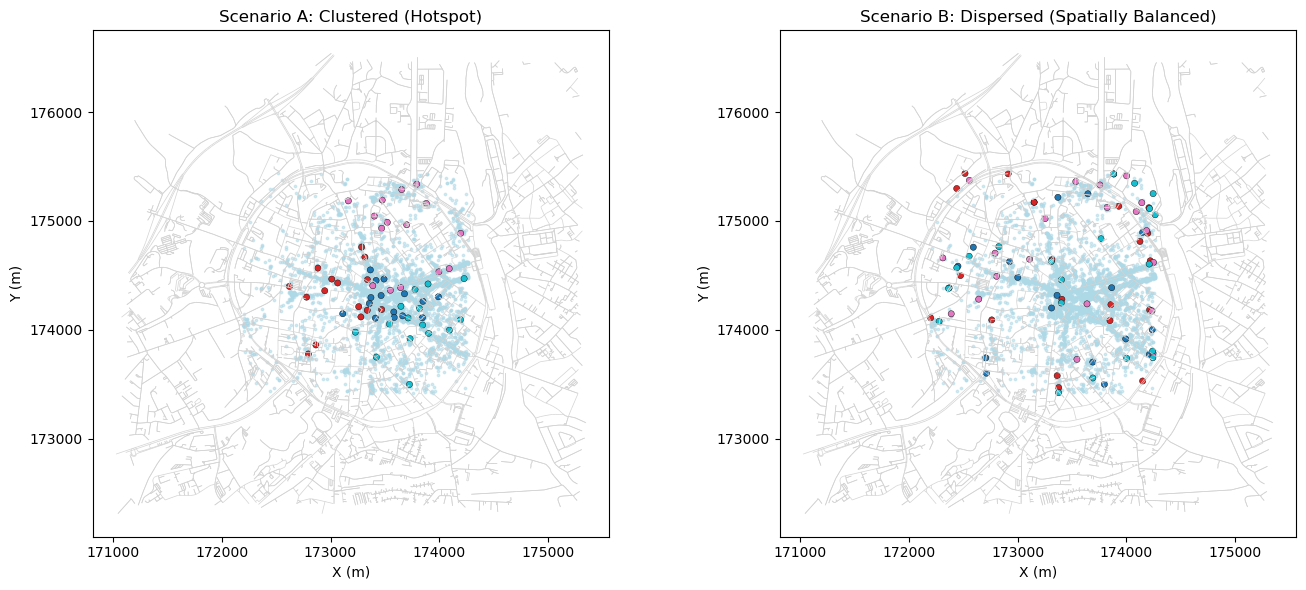

In [73]:
# Visualize both scenarios side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scenario A: Clustered
ax = axes[0]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped_filtered_level_one.plot(ax=ax, color='lightblue', markersize=3, alpha=0.5, label='All POIs')
customers_clustered.plot(ax=ax, column='cluster', cmap='tab10', markersize=20, legend=False, edgecolor='k', linewidth=0.3)
ax.set_title('Scenario A: Clustered (Hotspot)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Scenario B: Dispersed
ax = axes[1]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
fsq_poi_gdf_cropped_filtered_level_one.plot(ax=ax, color='lightblue', markersize=3, alpha=0.5, label='All POIs')
customers_dispersed.plot(ax=ax, column='carrier_id', cmap='tab10', markersize=20, edgecolor='k', linewidth=0.3)
ax.set_title('Scenario B: Dispersed (Spatially Balanced)')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

plt.tight_layout()
plt.show()

# Match locations to the network

In [37]:
def match_customers_to_links(
    customers_gdf: gpd.GeoDataFrame,
    network_gdf: gpd.GeoDataFrame,
    link_id_col: str = 'link_id',
) -> gpd.GeoDataFrame:
    """
    Match each customer to the nearest network link (edge).

    Parameters
    ----------
    customers_gdf : GeoDataFrame
        Customer point locations.
    network_gdf : GeoDataFrame
        Network links (LineString geometries).
    link_id_col : str
        Column name for link IDs in network_gdf.

    Returns
    -------
    GeoDataFrame
        Customers with added columns:
        - 'matched_link_id': ID of the nearest link
        - 'distance_to_link': distance (meters) to that link
        - 'snap_point': the closest point on the link geometry
    """
    from shapely.ops import nearest_points

    customers = customers_gdf.copy()
    
    # Prepare network links as a single unary union for fast nearest lookup
    # But we need per-link matching, so iterate
    link_geoms = network_gdf.geometry.values
    link_ids = network_gdf[link_id_col].values if link_id_col in network_gdf.columns else network_gdf.index.values

    matched_link_ids = []
    distances = []
    snap_points = []

    for pt in customers.geometry:
        min_dist = float('inf')
        best_link_id = None
        best_snap = None

        for link_id, link_geom in zip(link_ids, link_geoms):
            dist = pt.distance(link_geom)
            if dist < min_dist:
                min_dist = dist
                best_link_id = link_id
                # Get the closest point on the link
                _, snap_pt = nearest_points(pt, link_geom)
                best_snap = snap_pt

        matched_link_ids.append(best_link_id)
        distances.append(min_dist)
        snap_points.append(best_snap)

    customers['matched_link_id'] = matched_link_ids
    customers['distance_to_link'] = distances
    customers['snap_point'] = gpd.GeoSeries(snap_points, crs=customers.crs)

    return customers

In [38]:
def match_customers_to_links_fast(
    customers_gdf: gpd.GeoDataFrame,
    network_gdf: gpd.GeoDataFrame,
    link_id_col: str = 'link_id',
) -> gpd.GeoDataFrame:
    """
    Match each customer to the nearest network link (edge) using spatial index.
    
    Faster version using STRtree for large networks.

    Parameters
    ----------
    customers_gdf : GeoDataFrame
        Customer point locations.
    network_gdf : GeoDataFrame
        Network links (LineString geometries).
    link_id_col : str
        Column name for link IDs in network_gdf.

    Returns
    -------
    GeoDataFrame
        Customers with added columns:
        - 'matched_link_id': ID of the nearest link
        - 'distance_to_link': distance (meters) to that link
        - 'snap_point': the closest point on the link geometry
    """
    from shapely.strtree import STRtree
    from shapely.ops import nearest_points

    customers = customers_gdf.copy()
    network = network_gdf.copy().reset_index(drop=True)
    
    link_geoms = list(network.geometry.values)
    # Use link_id_col if present, otherwise fall back to index
    if link_id_col in network.columns:
        link_ids = network[link_id_col].values
    else:
        link_ids = network.index.values

    # Build spatial index
    tree = STRtree(link_geoms)

    matched_link_ids = []
    distances = []
    snap_points = []

    for pt in customers.geometry:
        # Query nearest geometry - returns index in Shapely >= 2.0
        nearest_idx = tree.nearest(pt)
        nearest_geom = link_geoms[nearest_idx]
        
        dist = pt.distance(nearest_geom)
        _, snap_pt = nearest_points(pt, nearest_geom)

        matched_link_ids.append(link_ids[nearest_idx])
        distances.append(dist)
        snap_points.append(snap_pt)

    customers['matched_link_id'] = matched_link_ids
    customers['distance_to_link'] = distances
    customers['snap_point'] = gpd.GeoSeries(snap_points, crs=customers.crs)

    return customers

## Match Customers to Network Links

In [39]:
# Match clustered customers to network links
customers_clustered_matched = match_customers_to_links_fast(
    customers_clustered,
    network_gdf_cropped4customer,
    link_id_col='link_id',
)
print(f"Matched {len(customers_clustered_matched)} clustered customers to links")
customers_clustered_matched[['cluster', 'matched_link_id', 'distance_to_link']].head(10)

Matched 40 clustered customers to links


,cluster,matched_link_id,distance_to_link
0,0,963873017_r_0,29.924842
1,0,527919914_62-527919914_63,0.576240
2,0,361902072_r_17-361902072_r_18,4.326217
3,0,361902073_r_31,1.928581
4,0,18132007_1,7.393338
5,0,510485129_r_5-510485129_r_6,20.559464
6,0,305552017_r_0,2.769711
7,0,588128120_21-588128120_22,2.489773
8,0,3991661_4-3991661_5-3991661_6-3991661_7-399166...,7.197624
9,0,132088819_14,0.943175


In [40]:
customers_clustered_matched

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat2_name,cat3_name,cat4_name,cat5_name,cat6_name,geometry,cluster,matched_link_id,distance_to_link,snap_point
0,4cdabc35930af04dd8a18697,Take-5,50.880824,4.700814,Schrijnmakersstraat 25,Leuven,Vlaams Gewest,3000,None,None,...,Breakfast Spot,None,None,None,None,POINT (173458.684 174487.723),0,963873017_r_0,29.924842,POINT (173440.198 174511.256)
1,1b271914c5954ffb0d5ff3df,Aubrion Sweets,50.878128,4.703635,Tiensestraat 33,Leuven,Vlaams-Brabant,3000,None,None,...,Food and Beverage Retail,Chocolate Store,None,None,None,POINT (173658.575 174188.705),0,527919914_62-527919914_63,0.576240,POINT (173658.438 174188.145)
2,5a13096d3149b9796eb94706,Inari Sushi Bar,50.879134,4.700393,Kortestraat 2,Leuven,Vlaams-Brabant,3000,None,None,...,Restaurant,Asian Restaurant,Japanese Restaurant,Sushi Restaurant,None,POINT (173429.883 174299.555),0,361902072_r_17-361902072_r_18,4.326217,POINT (173426.033 174301.529)
3,69f653eb6e5446a2a5455633,Oona Asian Restaurant & Bar,50.878977,4.699463,Parijsstraat 23,Leuven,Vlaams-Brabant,3000,None,None,...,Restaurant,None,None,None,None,POINT (173364.523 174281.83),0,361902073_r_31,1.928581,POINT (173362.597 174281.913)
4,5c17fb70cbcdee002c53067c,'t Wit Madammeke,50.878407,4.707213,Herbert Hooverplein,Leuven,Vlaams-Brabant,3000,None,None,...,Dessert Shop,None,None,None,None,POINT (173910.255 174220.888),0,18132007_1,7.393338,POINT (173915.626 174215.807)
5,549e5b25498e59f5865e37cd,Objets Trouvés,50.880395,4.696049,Brusselsestraat 94,Leuven,None,3000,None,None,...,Antique Store,None,None,None,None,POINT (173123.55 174438.505),0,510485129_r_5-510485129_r_6,20.559464,POINT (173140.117 174426.331)
6,4ddd2d95fa766a6d794d42b2,Night Shop Vismarkt,50.881388,4.699499,None,Leuven,Flemish Region,None,None,None,...,Convenience Store,None,None,None,None,POINT (173365.849 174550.038),0,305552017_r_0,2.769711,POINT (173367.522 174552.245)
7,52d12f36498e4bb5635bfbb8,Sumô,50.880285,4.700309,Mechelsestraat,None,None,3000,None,None,...,Fashion Retail,Shoe Store,None,None,None,POINT (173423.379 174427.571),0,588128120_21-588128120_22,2.489773,POINT (173425.022 174429.442)
8,66fd20ed75fc042d3fc26a23,Donuterie,50.879980,4.707782,Bondgenotenlaan 68,Leuven,None,3000,None,None,...,Donut Shop,None,None,None,None,POINT (173949.5 174396.058),0,3991661_4-3991661_5-3991661_6-3991661_7-399166...,7.197624,POINT (173944.116 174400.836)
9,55509e5e498e1d5fa80b6e6d,Loving Hut Leuven,50.879100,4.703120,Rector De Somerplein 13,Leuven,Vlaanderen,3000,None,None,...,Restaurant,None,None,None,None,POINT (173621.84 174296.67),0,132088819_14,0.943175,POINT (173621.219 174297.38)


In [41]:
# Match dispersed customers to network links
customers_dispersed_matched = match_customers_to_links_fast(
    customers_dispersed,
    network_gdf_cropped4customer,
    link_id_col='link_id',
)
print(f"Matched {len(customers_dispersed_matched)} dispersed customers to links")
customers_dispersed_matched[['grid_id', 'matched_link_id', 'distance_to_link']].head(10)

Matched 40 dispersed customers to links


,grid_id,matched_link_id,distance_to_link
0,0_2,3752553_r_4,47.712358
1,3_4,splitLink_304242040_r_1_2,3.855301
2,2_2,305551912_1,13.377568
3,1_0,461159364_0-461159364_1-461159363_0-366337447_...,5.533695
4,3_0,48247088_r_3-893781380_0,17.458699
5,4_2,3991664_r_0-3991664_r_1,49.255373
6,4_1,13523027_7,6.388143
7,3_0,3990534_0,5.008840
8,4_5,15216997_r_2,3.931510
9,3_0,589477287_0,16.358080


In [42]:
customers_dispersed_matched

,place_id,name,latitude,longitude,addr,locality,region,postcode,adm_region,post_town,...,cat3_name,cat4_name,cat5_name,cat6_name,geometry,grid_id,carrier_id,matched_link_id,distance_to_link,snap_point
0,5812828e38fa608e85918ebc,Koyens Kommunistisches Kraakpand,50.881733,4.686504,Brusselsestraat 165,Leuven,None,3000,None,None,...,Belgian Restaurant,None,None,None,POINT (172451.185 174584.42),0_2,0,3752553_r_4,47.712358,POINT (172434.348 174539.777)
1,616db2e33d590d0edbb7a344,Wolf Performance,50.887732,4.703071,Vaartkom 27,Leuven,None,3000,None,None,...,Bicycle Store,None,None,None,POINT (173614.059 175256.962),3_4,0,splitLink_304242040_r_1_2,3.855301,POINT (173613.532 175253.143)
2,669d49d73975e9236f5636a3,Crusco 7,50.881765,4.699147,Mechelsestraat 65A,Leuven,None,3000,None,None,...,Belgian Restaurant,None,None,None,POINT (173340.901 174591.884),2_2,0,305551912_1,13.377568,POINT (173329.463 174584.947)
3,4b7689c5f964a52003512ee3,Veeakker,50.874074,4.689880,Slachthuislaan 3,Leuven,Vlaams-Brabant,3000,None,None,...,Butcher,None,None,None,POINT (172692.429 173733.4),1_0,0,461159364_0-461159364_1-461159363_0-366337447_...,5.533695,POINT (172691.886 173727.893)
4,585713a40bc55b58b7263edf,TOPkot,50.873344,4.705588,None,Leuven,None,3000,None,None,...,Sports Bar,None,None,None,POINT (173798.452 173657.14),3_0,0,48247088_r_3-893781380_0,17.458699,POINT (173782.054 173651.146)
5,4cf8fc1ad1dd721e440aa69b,Belgacom Center LEUVEN Bondgenotenlaan (met/av...,50.880002,4.706682,Bondgenotenlaan 55,Leuven,None,3000,None,None,...,Mobile Phone Store,None,None,None,POINT (173872.104 174398.194),4_2,0,3991664_r_0-3991664_r_1,49.255373,POINT (173841.687 174359.452)
6,4b2a73e6f964a5207aa924e3,'A Zamara,50.875703,4.708405,Tiensestraat 123,Leuven,Vlaams-Brabant,3000,None,None,...,Italian Restaurant,None,None,None,POINT (173995.53 173920.47),4_1,0,13523027_7,6.388143,POINT (173998.851 173925.927)
7,4e7715d8ae60c32851d58199,De Roos,50.874185,4.700230,None,Leuven,Vlaams Gewest,None,None,None,...,None,None,None,None,POINT (173420.926 173748.956),3_0,0,3990534_0,5.008840,POINT (173417.926 173752.967)
8,4e37f359483bda3eb115bfc5,Drankencentrale ABC Drinks - Prik&Tik,50.889295,4.706906,Aarschotsesteenweg 4,Leuven,Vlaams-Brabant,3012,None,None,...,None,None,None,None,POINT (173883.139 175432.028),4_5,0,15216997_r_2,3.931510,POINT (173886.364 175429.779)
9,5294d6bc498ef28883d131ba,Tootsie's Kaffie- en Dreupelkot,50.874440,4.703653,Edward Van Evenstraat 15,Leuven,None,None,None,None,...,Coffee Shop,None,None,None,POINT (173661.699 173778.444),3_0,0,589477287_0,16.358080,POINT (173656.466 173793.943)


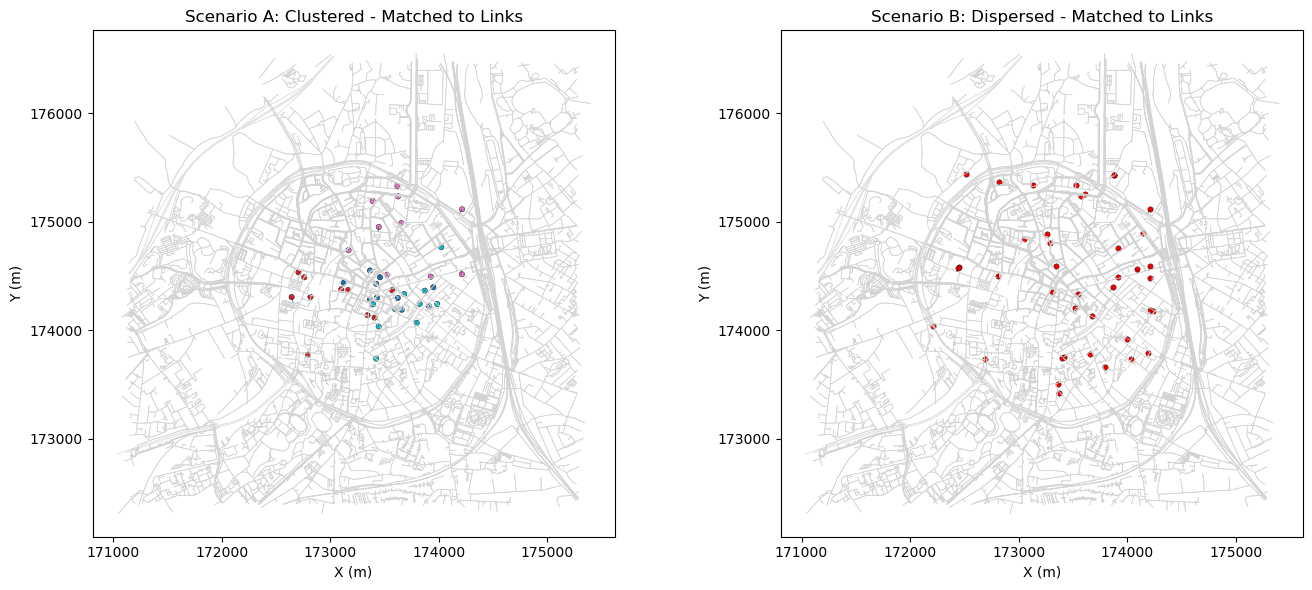

In [43]:
# Visualize matched customers with their snap points on the network
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scenario A: Clustered
ax = axes[0]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
customers_clustered_matched.plot(ax=ax, column='cluster', cmap='tab10', markersize=15, legend=False, edgecolor='k', linewidth=0.3, label='Customers')
# Draw lines from customer to snap point
for idx, row in customers_clustered_matched.iterrows():
    ax.plot([row.geometry.x, row.snap_point.x], [row.geometry.y, row.snap_point.y], 'k-', linewidth=0.5, alpha=0.5)
ax.set_title('Scenario A: Clustered - Matched to Links')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# Scenario B: Dispersed
ax = axes[1]
network_gdf_cropped.plot(ax=ax, color='lightgrey', linewidth=0.5)
customers_dispersed_matched.plot(ax=ax, color='red', markersize=15, edgecolor='k', linewidth=0.3, label='Customers')
# Draw lines from customer to snap point
for idx, row in customers_dispersed_matched.iterrows():
    ax.plot([row.geometry.x, row.snap_point.x], [row.geometry.y, row.snap_point.y], 'k-', linewidth=0.5, alpha=0.5)
ax.set_title('Scenario B: Dispersed - Matched to Links')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

plt.tight_layout()
plt.show()

In [46]:
''' Output the matched customers to csv file for further use (only need 'place_id, 'carrier_id/cluster', 'matched_link_id'') '''
demand_output_dir = r'data/randomDemand40Receivers'
customers_clustered_matched[['place_id', 'cluster', 'matched_link_id']].rename(columns={'cluster': 'carrier_id'}).to_csv(f'{demand_output_dir}/clustered/location_i01.csv.gz', index=False, compression='gzip')
customers_dispersed_matched[['place_id', 'carrier_id', 'matched_link_id']].to_csv(f'{demand_output_dir}/dispersed/location_i01.csv.gz', index=False, compression='gzip')

# Test

In [38]:
_ = pd.read_csv(f'{demand_output_dir}/dispersed/location_i01.csv.gz', compression='gzip')   
_

,place_id,carrier_id,matched_link_id
0,5812828e38fa608e85918ebc,0,3752553_r_4
1,616db2e33d590d0edbb7a344,0,splitLink_304242040_r_1_2
2,669d49d73975e9236f5636a3,0,305551912_1
3,4b7689c5f964a52003512ee3,0,366337447_r_2-366337447_r_3-461159363_r_0-4611...
4,585713a40bc55b58b7263edf,0,48247088_r_3-893781380_0
...,...,...,...
95,4da58bb9fa8cf9bcc8805a35,3,290143805_r_0-290143805_r_1-290143805_r_2
96,58b5ef2ddebdf6752c348ee1,3,589420372_0-589420372_1-589420372_2-589420371_...
97,62923bd16c06bd0090d16062,3,290184425_r_3
98,58bdbd2f91936a61c9326abb,3,1085097726_1
